# TEMP-U2, RMUX16, and MIO Extension Cards

This example demonstrates how to interact with the [TEMP-U2](https://zahner.de/products-details/addon-cards/temp-u2), [RMUX16](https://zahner.de/products-details/multiplexer/rmux16), and [MIO](https://zahner.de/products-details/addon-cards/mio) extension cards of the IM7 potentiostat using the [zahner_link](https://doc.zahner.de/im7/apis/zahner_link/python/) library. Each card provides specialized functionality that extends the workstation's capabilities beyond standard electrochemical measurements.

This notebook covers:
* **TEMP-U2 Single-Point Readings:** Acquiring temperature and analog input values with [MeasureIntegralJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.MeasureIntegralJob).
* **Asynchronous Channel Configuration:** Adding TEMP-U2 channels to a DC measurement using [Channel](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.Channel) objects and [UserHardwareSettings](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.UserHardwareSettings).
* **OCV with Additional Channels:** Running an Open Circuit Voltage measurement that records TEMP-U2 data alongside voltage and current.
* **Data Export:** Saving measurement data with additional channels to Zahner XML format.
* **RMUX16 Impedance Scan:** Measuring a single-frequency impedance point on all 16 relay multiplexer channels.
* **MIO Analog Outputs:** Setting analog output voltages on the MIO card.
* **MIO Digital I/O:** Controlling digital outputs and reading digital inputs, both as bitmasks and as individual pins.

Basic procedures like [DC calibration](https://doc.zahner.de/im7/faq/index.html#warm-up-dc-calibration) after warm-up are not covered in this example.

In [1]:
import zahner_link as zl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter

link = zl.ZahnerLinkExc("10.10.253.150", "1994")
link.connect()
print("Connected successfully")

Connected successfully


In [2]:
hardware_info_job = zl.control.GetHardwareInfoJob()
link.do_job(hardware_info_job)
hardware_info = hardware_info_job.get_job_result()

print("Detected extension cards:")
for card in hardware_info.cards:
    print(f"\t{card.symbol:8s} Serial: {card.serialnumber} Name: {card.name} ")

Detected extension cards:
	FUGE     Serial: 37222 Name: Function Generator 
	MIO      Serial: 40681 Name: Analog out & Digital I/O 
	TEMPU    Serial: 42390 Name: Temperature Measurement 
	PAD4     Serial: 43136 Name: Parallel Impedance Measurements 
	PAD      Serial: 43639 Name: Parallel Impedance Measurements 
	RMUX16   Serial: 44048 Name: 16 Channel Multiplexer 
	MAIN     Serial: 37128 Name: Zennium Potentiostat/Shunt 


## TEMP-U2 - Temperature and Analog Inputs

The TEMP-U2 extension card provides two thermocouple temperature inputs (`TEMP_IN1`, `TEMP_IN2`) and two general-purpose analog inputs (`ANALOG_IN1`, `ANALOG_IN2`). Each channel can be sampled through either of two ADC paths:

- `ADC_32`: High-precision 32-bit converter - slower but very accurate.
- `ADC_24`: Fast 24-bit converter - for continuous sampling during measurements.

The channel is addressed with a URI string in the format `TEMPU:1:<INPUT>~MAIN:1:<ADC>`. For example, `TEMPU:1:TEMP_IN1~MAIN:1:ADC_32` reads the first temperature input through the 32-bit ADC.

Hardware properties such as thermocouple type and line frequency filter can be configured using [SetHardwarePropertyJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.SetHardwarePropertyJob).

### Single-Point Readings with MeasureIntegralJob

A [MeasureIntegralJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.MeasureIntegralJob) performs a single integrated reading on a specified channel. This is useful for quick spot checks of temperature or voltage without running a full measurement.

The parameters are:
- `channel`: The channel URI, e.g. `"TEMPU:1:TEMP_IN1~MAIN:1:ADC_32"`
- `duration`: Integration time in seconds

Here we read the temperature input 1 and analog input 2 through the high-precision 32-bit ADC:

In [3]:
channels_to_read = [
    ("TEMPU:1:TEMP_IN1~MAIN:1:ADC_32", "Temperature Input 1"),
    ("TEMPU:1:ANALOG_IN2~MAIN:1:ADC_32", "Analog Input 2"),
]

for channel_uri, label in channels_to_read:
    job = zl.control.MeasureIntegralJob(channel=channel_uri, duration=0.1)
    link.do_job(job)
    value = job.get_job_result()
    print(f"{label:25s} ({channel_uri}): {value}")

Temperature Input 1       (TEMPU:1:TEMP_IN1~MAIN:1:ADC_32): 25.071325737408916
Analog Input 2            (TEMPU:1:ANALOG_IN2~MAIN:1:ADC_32): 4.241620502109632


### Asynchronous Channel Configuration

To record TEMP-U2 channels continuously during a DC measurement (such as OCV or polarization), they need to be added to the hardware sampling configuration. Channels that are not part of the main potentiostat's synchronous sampling path are automatically classified as **asynchronous channels**. These are sampled sequentially after the synchronous channels and appear as additional tracks in the measurement data.

The setup involves three steps:
1. Retrieve the default configuration using [HardwareSettingsHelper.get_config_for_main_potentiostat()](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.HardwareSettingsHelper.get_config_for_main_potentiostat).
2. Extend the channel list with [Channel](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.Channel) objects for the TEMP-U2 inputs. Each channel requires a URI, a `dimension` name (used as the track name in the result data), a `unit`, and a [UserPolynomial](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.UserPolynomial) for value scaling.
3. Apply the new configuration with [SetHardwareSettingsJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.SetHardwareSettingsJob).

The IM7 will automatically split the channels into synchronous and asynchronous groups based on their hardware paths.

In [4]:
config = zl.HardwareSettingsHelper.get_config_for_main_potentiostat()
config.add_channel(
    zl.Channel(
        uri="TEMPU:1:TEMP_IN1~MAIN:1:ADC_24",
        dimension="T1",
        unit="°C",
        polynomial=zl.UserPolynomial([0.0, 1.0]),
    )
)
config.add_channel(
    zl.Channel(
        uri="TEMPU:1:ANALOG_IN2~MAIN:1:ADC_24",
        dimension="A2",
        unit="V",
        polynomial=zl.UserPolynomial([0.0, 1.0]),
    )
)

link.do_job(zl.control.SetHardwareSettingsJob(config=config))
print("Hardware configuration updated with TEMP-U2 async channels")

Hardware configuration updated with TEMP-U2 async channels


### OCV Measurement with Asynchronous Channels

Now we run an [OcvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.OcvJob) for 5 seconds at 2 Hz output data rate. Because the TEMP-U2 channels have been added to the configuration, the resulting [DcDataset](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.DcDataset) will contain the standard `time`, `voltage`, and `current` tracks as well as the `T1` and `A2` tracks from the TEMP-U2 card.

After retrieving the data, we export it to a Zahner XML file using [Measurement](https://doc.zahner.de/im7/apis/zahner_link/python/pages/xml.html#zahner_link.xml.Measurement) and [ZXmlExporter](https://doc.zahner.de/im7/apis/zahner_link/python/pages/xml.html#zahner_link.xml.ZXmlExporter). The exported `.zmx` file will contain all tracks, including the TEMP-U2 channels.

In [5]:
ocv_job = zl.meas.OcvJob(duration=5, output_data_rate=2)
link.do_job(ocv_job)
ocv_data = link.get_job_result_data(ocv_job)

print(f"Recorded {ocv_data.get_row_count()} data points")
print(f"Available tracks: {list(ocv_data.get_dc_tracks().keys())}")
print()

for name, track in ocv_data.get_dc_tracks().items():
    (
        print(f"{name:12s}: {track[:3]} ... {track[-1:]}")
        if len(track) > 3
        else print(f"{name:12s}: {track}")
    )

xml_measurement = zl.xml.Measurement(ocv_data)
exporter = zl.xml.ZXmlExporter()
exporter.set_compact_xml(False)
exporter.save_as_file_standalone(xml_measurement, "ocv_with_tempu.zmx")
print("\nData exported to ocv_with_tempu.zmx")

Recorded 10 data points
Available tracks: ['A2', 'T1', 'current', 'shunt', 'time', 'voltage']

A2          : [4.243217763459921, 4.243247054023932, 4.243251252353622] ... [4.243234831392263]
T1          : [23.875353941077595, 23.90717072206358, 23.84416434968132] ... [23.859074938554322]
current     : [4.2495226708879355e-13, 4.152609376837767e-13, 4.700235608402345e-13] ... [4.590324975890867e-13]
shunt       : [11.0, 11.0, 11.0] ... [11.0]
time        : [0.5, 1.0, 1.5] ... [5.0]
voltage     : [-0.00011688045928347619, -0.00011547148547234828, -0.00011528134713797463] ... [-0.0001209026163567652]

Data exported to ocv_with_tempu.zmx


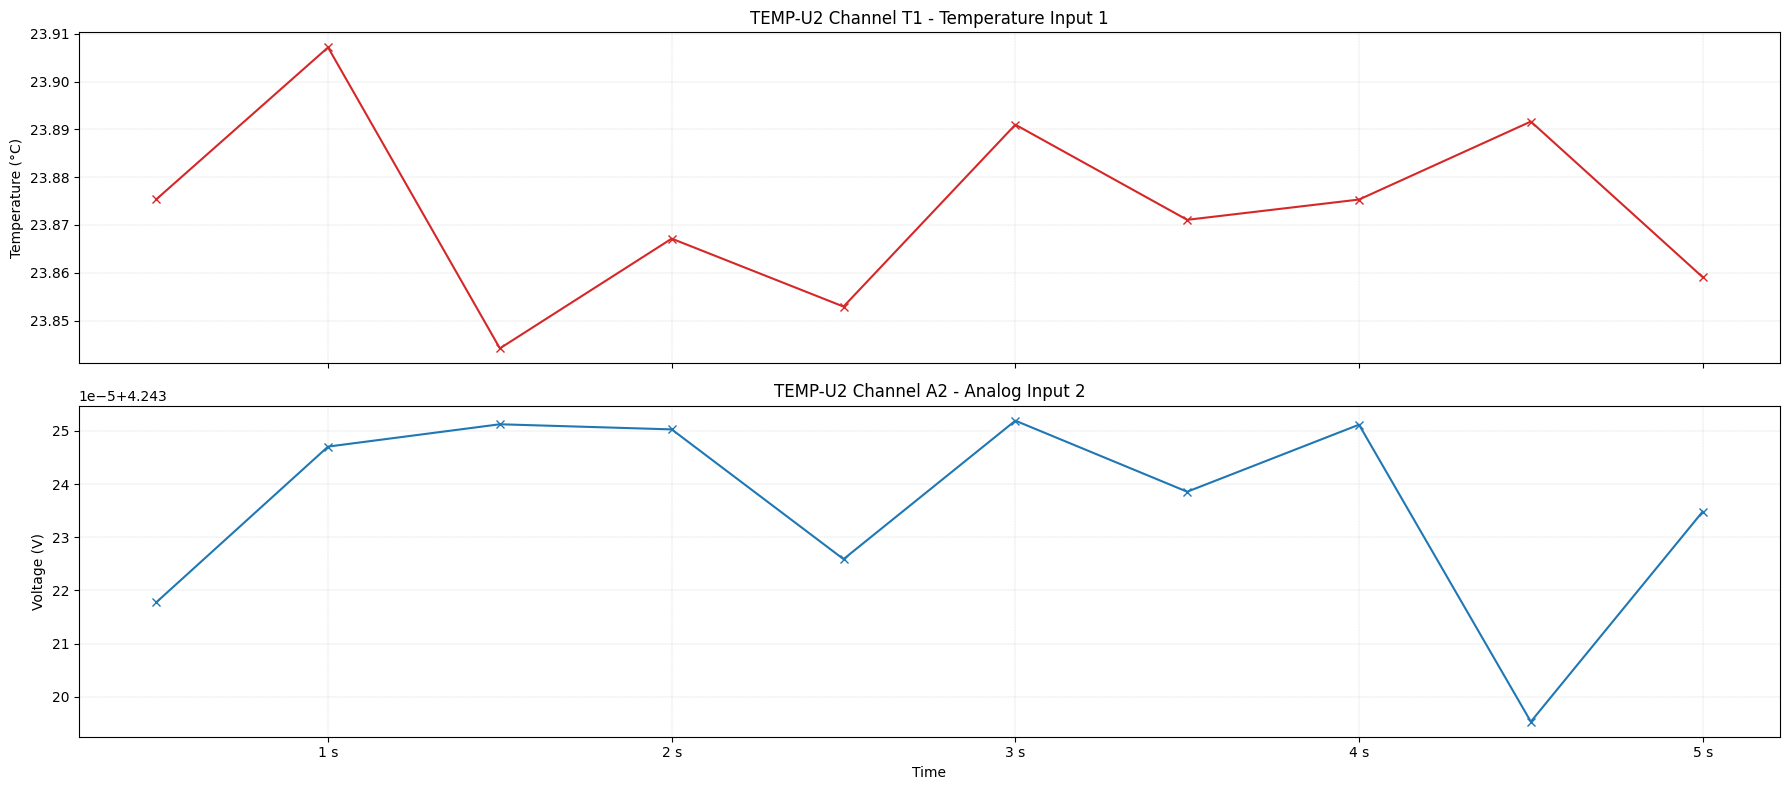

In [6]:
tracks = ocv_data.get_dc_tracks()
time_track = tracks["time"]

fig, (ax_temp, ax_analog) = plt.subplots(2, 1, sharex=True)

ax_temp.plot(time_track, tracks["T1"], marker="x", color="tab:red")
ax_temp.set_ylabel("Temperature (°C)")
ax_temp.set_title("TEMP-U2 Channel T1 - Temperature Input 1")
ax_temp.grid(linestyle="dashed", linewidth=0.2)
ax_temp.xaxis.set_major_formatter(EngFormatter(unit="s"))

ax_analog.plot(time_track, tracks["A2"], marker="x", color="tab:blue")
ax_analog.set_ylabel("Voltage (V)")
ax_analog.set_xlabel("Time")
ax_analog.set_title("TEMP-U2 Channel A2 - Analog Input 2")
ax_analog.grid(linestyle="dashed", linewidth=0.2)
ax_analog.xaxis.set_major_formatter(EngFormatter(unit="s"))

fig.set_size_inches(18, 8)
fig.tight_layout()
plt.show()

### EIS Measurement with Asynchronous Channels

Since the TEMP-U2 channels are still configured as asynchronous channels, they are also sampled at each frequency point during EIS measurements. This allows us to monitor the temperature throughout the impedance spectrum and verify thermal stability.

We switch the potentiostat on in potentiostatic mode and run an [EisGenerateJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisGenerateJob) sweeping from 1 kHz up to 100 kHz, then down to 1 Hz. The resulting [EisDataset](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.EisDataset) contains both the impedance data and the temperature track `T1`, accessible via `get_path_data("T1").get_dc_track()`.

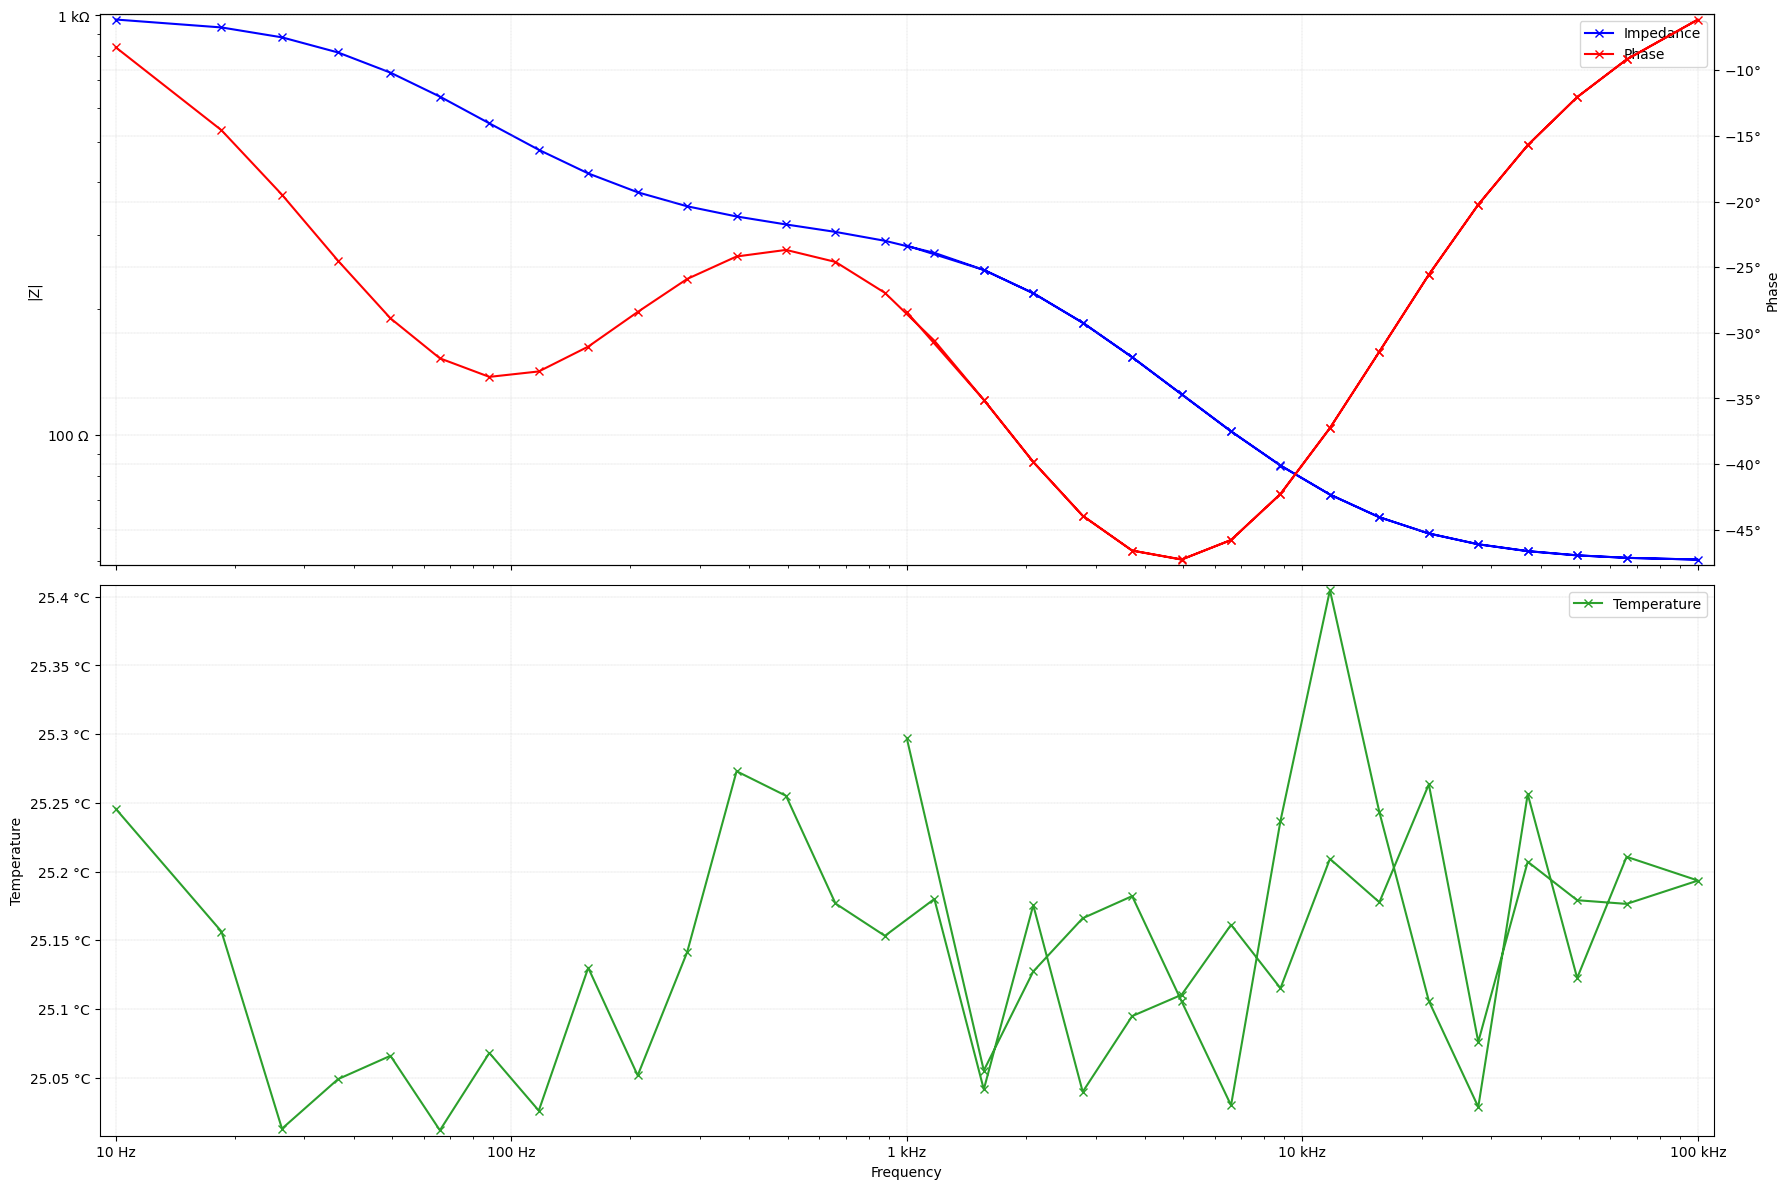

0

In [8]:
switch_on_job = zl.control.SwitchOnJob(
    potentiostat="MAIN:1:POT",
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat="MAIN:1:POT")
link.do_job(switch_on_job)

eis_async_job = zl.meas.EisGenerateJob(
    bias=0,
    min_frequency=10,
    max_frequency=1e5,
    start_frequency=1e3,
    points_per_decade_upper=8,
    points_per_decade_lower=5,
    pre_duration=0,
    pre_waves=1,
    meas_duration=0.1,
    meas_waves=4,
    amplitude=1e-2,
)
link.do_job(eis_async_job)
link.do_job(switch_off_job)
eis_async_data = link.get_job_result_data(eis_async_job)

def plot_spectra_with_temperature(data: zl.EisDataset):
    frequencies = data.get_frequencies()
    impedances = data.get_impedance_data().get_calculated_complex_impedance_track()
    temperatures = data.get_path_data("T1").get_dc_track()

    fig, (impedance_ax, temp_ax) = plt.subplots(
        2,
        1,
        sharex=True,
    )
    phase_ax = impedance_ax.twinx()

    (impedance_line,) = impedance_ax.loglog(
        frequencies,
        np.absolute(impedances),
        marker="x",
        color="blue",
        label="Impedance",
    )

    (phase_line,) = phase_ax.semilogx(
        frequencies,
        np.angle(impedances, deg=True),
        marker="x",
        color="red",
        label="Phase",
    )

    impedance_ax.yaxis.set_major_formatter(EngFormatter(unit=r"$\Omega$"))
    impedance_ax.set_ylabel(r"|Z|")
    impedance_ax.grid(linestyle="dashed", linewidth=0.2)
    margin = 0.01
    impedance_ax.margins(margin)

    phase_ax.yaxis.set_major_formatter(EngFormatter(unit="$°$", sep=""))
    phase_ax.set_ylabel("Phase")
    phase_ax.grid(linestyle="dashed", linewidth=0.2)
    phase_ax.margins(margin)
    impedance_ax.legend(handles=[impedance_line, phase_line])

    (temp_line,) = temp_ax.semilogx(
        frequencies,
        temperatures,
        marker="x",
        color="tab:green",
        label="Temperature",
    )
    temp_ax.xaxis.set_major_formatter(EngFormatter(unit="Hz"))
    temp_ax.yaxis.set_major_formatter(EngFormatter(unit=r"°C"))
    temp_ax.set_ylabel("Temperature")
    temp_ax.set_xlabel("Frequency")
    temp_ax.grid(linestyle="dashed", linewidth=0.2)
    temp_ax.margins(margin)
    temp_ax.legend(handles=[temp_line])

    fig.set_size_inches(18, 12)
    fig.tight_layout()
    plt.show()


plot_spectra_with_temperature(eis_async_data)

xml_measurement = zl.xml.Measurement(eis_async_data)
exporter.save_as_file_standalone(xml_measurement, "eis_with_tempu.zmx")

In [ ]:
link.do_job(
    zl.control.SetHardwareSettingsJob(
        config=zl.HardwareSettingsHelper.get_config_for_main_potentiostat()
    )
)
print("Hardware configuration restored to default")

Hardware configuration restored to default


## RMUX16 - Relay Multiplexer

The RMUX16 is a 16-channel relay multiplexer that allows you to sequentially connect up to 16 different electrochemical cells to a single potentiostat. The active channel is selected by setting the `MUX_CHANNEL` property on the RMUX16 card using [SetHardwarePropertyJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.SetHardwarePropertyJob):

- `value=1` to `value=16`: Select channel 1 through 16.
- `value=0`: Deselect all channels (open relay).

A typical workflow loops over all channels, switching the relay before each measurement. In this example, we measure a single impedance point at 1 kHz on each channel using [EisFrequencyTableJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisFrequencyTableJob).

### Single-Point Impedance on All 16 Channels

For each channel, the sequence is:
1. Set `MUX_CHANNEL` to the desired channel number.
2. Switch on the potentiostat in potentiostatic mode at 0 V bias.
3. Run a single-frequency EIS measurement at 1 kHz.
4. Switch off the potentiostat.
5. Extract the impedance magnitude and phase from the [EisDataset](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.EisDataset).

After the scan, the multiplexer is reset to channel 0 (all relays open).

In [ ]:
switch_on_job = zl.control.SwitchOnJob(
    potentiostat="MAIN:1:POT",
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat="MAIN:1:POT")

print(f"{'Channel':>9s}  {'|Z|':>14s}  {'Phase':>10s}")
print("-" * 38)

for channel in range(1, 17):
    link.do_job(
        zl.control.SetHardwarePropertyJob(
            uri="RMUX16:1", key="MUX_CHANNEL", value=channel
        )
    )

    link.do_job(switch_on_job)

    eis_job = zl.meas.EisFrequencyTableJob(
        {
            "bias": 0.0,
            "spectrum": [
                {
                    "frequency": 50,
                    "amplitude": 0.1,
                    "pre_duration": 0.1,
                    "pre_waves": 1,
                    "meas_duration": 0.2,
                    "meas_waves": 3,
                }
            ],
        }
    )
    link.do_job(eis_job)
    link.do_job(switch_off_job)

    eis_data = link.get_job_result_data(eis_job)
    impedance = eis_data.get_impedance_data().get_calculated_complex_impedance_track()[
        0
    ]
    magnitude = np.abs(impedance)
    phase = np.angle(impedance, deg=True)

    ohm_fmt = EngFormatter(unit="\u03a9", places=3)
    print(f"{channel:9d}  {ohm_fmt.format_eng(magnitude):>14s}  {phase:>9.2f}°")

link.do_job(
    zl.control.SetHardwarePropertyJob(uri="RMUX16:1", key="MUX_CHANNEL", value=0)
)
print("\nMultiplexer reset to channel 0 (all relays open)")

  Channel             |Z|       Phase
--------------------------------------
        1       989.683 Ω      -0.00°
        2        1.084 kΩ      -0.00°
        3        1.809 kΩ      -0.01°
        4        1.106 kΩ      -0.00°
        5        2.821 kΩ      -0.00°
        6        1.257 kΩ      -0.00°
        7        1.382 kΩ      -0.00°
        8        1.989 kΩ      -0.00°
        9        4.297 kΩ      -0.00°
       10        1.498 kΩ      -0.01°
       11        2.483 kΩ      -0.00°
       12        1.673 kΩ      -0.00°
       13        1.970 kΩ      -0.00°
       14        3.724 kΩ      -0.01°
       15        2.455 kΩ      -0.00°
       16        2.194 kΩ      -0.00°

Multiplexer reset to channel 0 (all relays open)


## MIO - Digital and Analog I/O

The MIO extension card provides general-purpose I/O capabilities:

- **4 analog outputs** (`ANALOG_OUT:1` through `ANALOG_OUT:4`): Each can output a voltage in the range of ±10 V.
- **4 digital outputs** (`DIGITAL_OUT`): Accent controllable individually or as a 4-bit bitmask.
- **Digital inputs** (`DIGITAL_IN`): Readable individually or as a bitmask.

All I/O is controlled through [SetHardwarePropertyJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.SetHardwarePropertyJob) and [GetHardwarePropertyJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.GetHardwarePropertyJob) with `uri="MIO:1"`.

### Analog Outputs

Before working with the digital I/O, we set all four analog outputs to 4 V. This provides the supply voltage needed by the external test adapter circuitry connected to the digital pins.

Each analog output is addressed with the key `ANALOG_OUT:{index}` where the index ranges from 1 to 4.

In [ ]:
for i in range(1, 5):
    link.do_job(
        zl.control.SetHardwarePropertyJob(uri="MIO:1", key=f"ANALOG_OUT:{i}", value=4.0)
    )
    read_job = zl.control.GetHardwarePropertyJob(uri="MIO:1", key=f"ANALOG_OUT:{i}")
    link.do_job(read_job)
    print(f"ANALOG_OUT:{i} set to {read_job.get_job_result():.1f} V")

ANALOG_OUT:1 set to 4.0 V
ANALOG_OUT:2 set to 4.0 V
ANALOG_OUT:3 set to 4.0 V
ANALOG_OUT:4 set to 4.0 V


### Digital Outputs - All Pins at Once

The four digital output pins can be controlled simultaneously by writing a 4-bit bitmask to the `DIGITAL_OUT` key. Each bit corresponds to one pin (bit 0 → pin 1, bit 3 → pin 4). For example:

- `0xF` (`1111`): All four pins HIGH.
- `0x0` (`0000`): All four pins LOW.
- `0xA` (`1010`): Pins 2 and 4 HIGH, pins 1 and 3 LOW.
- `0x5` (`0101`): Pins 1 and 3 HIGH, pins 2 and 4 LOW.

In [ ]:
patterns = [0x0, 0xA, 0x5, 0xF, 0x0]

for pattern in patterns:
    link.do_job(
        zl.control.SetHardwarePropertyJob(uri="MIO:1", key="DIGITAL_OUT", value=pattern)
    )
    read_job = zl.control.GetHardwarePropertyJob(uri="MIO:1", key="DIGITAL_OUT")
    link.do_job(read_job)
    readback = read_job.get_job_result()
    print(
        f"Set: 0x{pattern:X} ({pattern:04b})  →  Read: 0x{readback:X} ({readback:04b})"
    )

Set: 0x0 (0000)  →  Read: 0x0 (0000)
Set: 0xA (1010)  →  Read: 0xA (1010)
Set: 0x5 (0101)  →  Read: 0x5 (0101)
Set: 0xF (1111)  →  Read: 0xF (1111)
Set: 0x0 (0000)  →  Read: 0x0 (0000)


### Digital Outputs - Individual Pins

Individual digital output pins can also be controlled one at a time using the key `DIGITAL_OUT:{index}` with a boolean value. This is convenient when only a single pin needs to change without affecting the others.

In [ ]:
for i in range(1, 5):
    link.do_job(
        zl.control.SetHardwarePropertyJob(
            uri="MIO:1", key=f"DIGITAL_OUT:{i}", value=True
        )
    )
    read_job = zl.control.GetHardwarePropertyJob(uri="MIO:1", key=f"DIGITAL_OUT:{i}")
    link.do_job(read_job)
    print(f"Pin {i}: set HIGH → read {read_job.get_job_result()}")

    link.do_job(
        zl.control.SetHardwarePropertyJob(
            uri="MIO:1", key=f"DIGITAL_OUT:{i}", value=False
        )
    )
    read_job = zl.control.GetHardwarePropertyJob(uri="MIO:1", key=f"DIGITAL_OUT:{i}")
    link.do_job(read_job)
    print(f"Pin {i}: set LOW  → read {read_job.get_job_result()}")

Pin 1: set HIGH → read True
Pin 1: set LOW  → read False
Pin 2: set HIGH → read True
Pin 2: set LOW  → read False
Pin 3: set HIGH → read True
Pin 3: set LOW  → read False
Pin 4: set HIGH → read True
Pin 4: set LOW  → read False


### Digital Inputs - All Pins at Once

The digital input state of all pins can be read as a single bitmask using the `DIGITAL_IN` key. The returned integer represents the combined state of all input pins.

In [ ]:
read_job = zl.control.GetHardwarePropertyJob(uri="MIO:1", key="DIGITAL_IN")
link.do_job(read_job)
value = read_job.get_job_result()
print(f"DIGITAL_IN: 0x{value:X} ({value:04b})")

DIGITAL_IN: 0x6 (0110)


### Digital Inputs - Individual Pins

Individual input pins can be read using the key `DIGITAL_IN:{index}`, which returns the state of a single pin.

In [ ]:
for i in range(1, 5):
    read_job = zl.control.GetHardwarePropertyJob(uri="MIO:1", key=f"DIGITAL_IN:{i}")
    link.do_job(read_job)
    state = read_job.get_job_result()
    print(f"Pin {i}: {state}")

Pin 1: False
Pin 2: True
Pin 3: True
Pin 4: False


In [ ]:
for i in range(1, 5):
    link.do_job(
        zl.control.SetHardwarePropertyJob(uri="MIO:1", key=f"ANALOG_OUT:{i}", value=0.0)
    )
print("All analog outputs reset to 0 V")

All analog outputs reset to 0 V


## Disconnect

Finally, we disconnect from the IM7. Data that was already retrieved from completed jobs remains valid and can still be used after disconnecting.

In [ ]:
link.disconnect()